# Setup

In [2]:
import os
import re
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from nmr_processing.leonmr import xf2, xf2_peak_pick
from lmfit import Parameters, minimize, report_fit, create_params

datadir = '/Users/tylerpennebaker/Library/CloudStorage/Box-Box/LGES subgroup/FRL II/Raw data/Selective Inversion/NMR Data/data/500.TP-2025.06.18_6Li_LZC+LPSC'
sir_exp = '22'
satrec_exp = '23'
site_labels = ['LPSC', 'LZC']
dataset_types = ['satrec', 'sir']

# Read in data

In [3]:
def read_t1ints(path, delay_offset=True, normalize=True):
    times = []
    ints = []

    with open(path, 'r') as file:
        line = file.readline() # skip first line
        line = file.readline()
        while not line.startswith('-'):
            times.append(float(line.split(' ')[0]))  # in seconds

            line = file.readline()
            n_sites = int(line.split(' ')[2])
            if not ints:
                ints = [[] for i in range(n_sites)]  # gotta be a better way
            for i in range(n_sites):
                line = file.readline()
                integral = float(line.split(' ')[1])  # integral is middle number
                ints[i].append(integral)

            line = file.readline()  # start next line

    # print('finished reading')
    times = np.array(times)
    ints = np.array(ints).T
    if normalize:
        # ints = (ints - np.min(ints))/(np.max(ints) - np.min(ints))
        ints = ints/np.max(ints)
    # print('finished np')

    if delay_offset:
        acqus = path.replace('t1ints.txt', '../../acqus')
        # print(f'acqus file: {acqus}')
        with open(acqus, "rb") as input:
            for line in input:
                # print(line.decode())
                if "##$P= (0..63)" in line.decode():
                    line = next(input)
                    linestr = line.decode()
                    P = (linestr.strip("\n").split(" "))
                    P2 = float(P[2])
        times += (P2 * 1e-6)/2
    # print('finished offset')

    return {'time_points':times, 'intensities':ints}

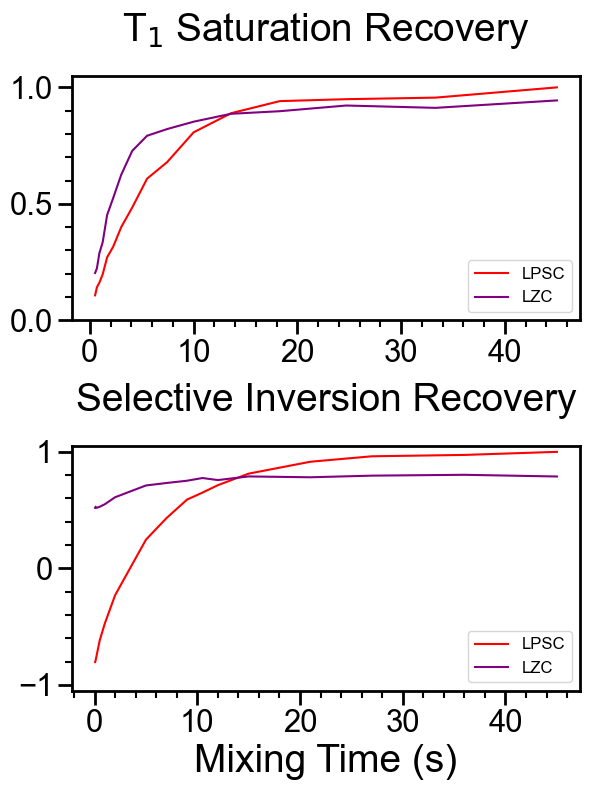

In [4]:
sirdata = read_t1ints(datadir+'/'+sir_exp+'/pdata/1/t1ints.txt')
satrecdata = read_t1ints(datadir+'/'+satrec_exp+'/pdata/1/t1ints.txt')
data_dict = {'satrec':satrecdata, 'sir':sirdata}

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.plot(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['red','purple'][site], label=site_labels[site])
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.05, 1.05])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

In [5]:
sirdata

{'time_points': array([ 0.0575,  0.1075,  0.2075,  0.5075,  1.0075,  2.0075,  5.0075,
         7.0075,  9.0075, 10.5075, 12.0075, 15.0075, 21.0075, 27.0075,
        36.0075, 45.0075]),
 'intensities': array([[-0.80445108,  0.51968912],
        [-0.79036758,  0.52923237],
        [-0.74709582,  0.51958681],
        [-0.61814222,  0.52877807],
        [-0.47199444,  0.55071713],
        [-0.22986127,  0.6105645 ],
        [ 0.24621161,  0.71144965],
        [ 0.43139878,  0.73271382],
        [ 0.59033472,  0.75219269],
        [ 0.65007134,  0.77535293],
        [ 0.71404689,  0.75785087],
        [ 0.81310074,  0.78899996],
        [ 0.91512634,  0.78179958],
        [ 0.96199407,  0.79585962],
        [ 0.9737178 ,  0.80306938],
        [ 1.        ,  0.78849685]])}

# Read in mechanism settings

In [6]:
def read_mch_params(lines, n_expected, specify_vary=False):
    """
    Reads a line from the given iterator `lines` and returns the parameters.

    If `specify_vary` is True, it also reads whether the parameters should be
    varied from the next line. Otherwise, it assumes the user will be asked
    about constraints later.
    """

    param_guess = list(map(float, next(lines).split()))
    assert len(param_guess) == n_expected

    if specify_vary:
        param_vary = list(map(bool, map(int, next(lines).split())))
        assert len(param_vary) == n_expected
    else:
        param_vary = None

    return param_guess, param_vary


def read_mch_file(filename, specify_vary=True):
    print(f"Specifying vary: {specify_vary}")
    with open(filename, 'r') as file:
        lines = file.readlines()

    lines = iter([line.strip() for line in lines
                  if line.strip() and not line.startswith('#')])

    # Title line
    mech_title = next(lines)
    print(f"Mechanism title: {mech_title}")

    # Read number of sites and processes
    n_sites, n_procs = map(int, next(lines).split())

    # Read T1 rate(r1), M0 and Minf guesses, and check against number of sites
    r1_guess, r1_vary = read_mch_params(lines, n_sites,
                                        specify_vary=specify_vary)
    minf_guess, minf_vary = read_mch_params(lines, n_sites,
                                            specify_vary=specify_vary)
    m0_guess, m0_vary = read_mch_params(lines, n_sites,
                                        specify_vary=specify_vary)

    # Read parameters for each process
    processes = []
    for i in range(n_procs):
        # First line of each process block specifies the rate constant k
        # and whether it should be varied or not
        if specify_vary:
            k_guess_str, k_vary_str = next(lines).split()
            k_guess = float(k_guess_str)
            k_vary = bool(int(k_vary_str))
        else:
            k_guess = float(next(lines))
            k_vary = None

        # Initialize diagonal matrix for the process
        exch_mat = np.zeros((n_sites, n_sites))

        # Read the nonzero off-diagonals associated with the process,
        # and add them to the matrix
        n_off_diagonals = int(next(lines))
        for j in range(n_off_diagonals):
            row_str, col_str, val_str = next(lines).split()
            row = int(row_str)  # Row of off-diagonal element
            col = int(col_str)  # Column of off-diagonal element
            val = -float(val_str)  # Invert sign as per original code
            exch_mat[row, col] = val
            # print(f"VAL: {val}")

        process = {
            'k_guess': k_guess,
            'k_vary': k_vary,
            'matrix': exch_mat
        }
        processes.append(process)

    # If not specifying vary, ask the user for each parameter
    if not specify_vary:
        def ask_vary(param_name, guesses):
            print(f"Should {param_name} parameters vary during fitting?")
            vary = []
            for i, guess in enumerate(guesses):
                while True:
                    prompt = f"  Site {i+1} ({param_name} = {guess}): [y/n] "
                    resp = input(prompt).strip().lower()
                    if resp in ('y', 'n', 'yes', 'no'):
                        vary.append(resp[0] == 'y')
                        break
                    else:
                        print("Please enter 'y' or 'n'.")
            return vary

        r1_vary = ask_vary("R1", r1_guess)
        minf_vary = ask_vary("Minf", minf_guess)
        m0_vary = ask_vary("M0", m0_guess)

        k_vary = ask_vary("k", [proc['k_guess'] for proc in processes])
        for i, proc in enumerate(processes):
            proc['k_vary'] = k_vary[i]

    const_dict = {
        'title': mech_title,
        'n_sites': n_sites,
        'n_procs': n_procs,
        'matrices': []
    }

    # TODO: Remove 'guess' from key names
    pars_dict = {
        'r1_guess': r1_guess,
        'r1_vary': r1_vary,
        'minf_guess': minf_guess,
        'minf_vary': minf_vary,
        'm0_guess': m0_guess,
        'm0_vary': m0_vary,
        'k_guess': [],
        'k_vary': []
    }
    for proc in processes:
        pars_dict['k_guess'].append(proc['k_guess'])
        pars_dict['k_vary'].append(proc['k_vary'])
        const_dict['matrices'].append(proc['matrix'])

    assert all(type(vary) is bool for vary in r1_vary + minf_vary + m0_vary), \
        "All vary parameters should be boolean values."

    return const_dict, pars_dict

In [7]:
const_dict, pars_dict = read_mch_file(f'{datadir}/{sir_exp}.mch')
const_dict

Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 22


{'title': 'Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 22',
 'n_sites': 2,
 'n_procs': 1,
 'matrices': [array([[ 0.    , -1.    ],
         [-0.9366,  0.    ]])]}

# Fit both datasets

In [8]:
# NEW FOR THIS TASK

def model_magnetization(params, const_dict, time_points, dataset='t1ir'):
    """
    Compute the model magnetization for all time points and sites.

    params: lmfit.Parameters object
    const_dict: mechanism dictionary
    time_points: list of time points to calculate magnetization for

    Returns: 2D array of calculated magnetizations.
    """

    n_sites = const_dict['n_sites']
    n_procs = const_dict['n_procs']
    time_points = np.array(time_points)
    n_points = len(time_points)

    v = params.valuesdict()

    minf = np.array([v[f'lpsc_{dataset}_minf'], v[f'lzc_{dataset}_minf']])
    m0minf = np.array([v[f'lpsc_{dataset}_m0'], v[f'lzc_{dataset}_m0']]) - minf

    # Build exchange matrix for each process and sum
    # Off-diagonals are already negative in the const_dict, scaled here by rate
    exch_mat = np.zeros((n_sites, n_sites))
    exch_mat += const_dict['matrix'] * v['rate']

    # Add relaxation rates to diagonal
    exch_mat[0, 0] += 1/v['lpsc_t1']
    exch_mat[1, 1] += 1/v['lzc_t1']

    # Add (subtract negative number) exchange portion to diagonal
    for i in range(n_sites):
        for j in range(n_sites):
            if j != i:
                exch_mat[i, i] -= exch_mat[i, j]

    # print("Full Matrix:")
    # print(exch_mat)

    mags = np.zeros((n_points, n_sites))
    for i, t in enumerate(time_points):
        mags[i, :] = scipy.linalg.expm(-exch_mat * t) @ m0minf + minf

    # print(m0minf)
    # print(minf)
    # print(m0minf + minf)

    # print(mags)
    return mags


def calc_residuals(params, const_dict, data_dict):
    residuals = []
    for dataset, data in data_dict.items():
        time_points = data['time_points'][np.newaxis].T
        # other = dataset_types[1-dataset_types.index(dataset)]

        # new_params = Parameters()
        # for key, val in params.items():
        #     if other in key:
        #         continue
        #     elif dataset in key:
        #         new_key = key.replace(f'_{dataset}', '')
        #         new_params[new_key] = val
        #     else:
        #         new_params[key] = val

        mags = model_magnetization(params, const_dict, time_points,
                                   dataset)
        obs = np.array(data['intensities'])

        # residuals.extend(list(((mags - obs)).flatten()))

        # weights = time_points ** -0.5

        weights = np.array([1, 1, 1, 1, 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
        # weights[0] = 10
        # weights[1] = 10
        # weights[2] = 10
        # weights[-1] = 0

        # weights = 2 * (5 ** -time_points) + 1

        weights = weights[np.newaxis].T
        weights.reshape((16,1))
        residuals.extend(list((weights * (mags - obs)).flatten()))

    return residuals


def calc_mags(params, const_dict, data_dict):
    calc = {}
    for dataset, data in data_dict.items():
        time_0 = 0.0
        time_f = data['time_points'][-1]
        times_smooth = np.linspace(time_0, time_f, 1001)

        mags_smooth = model_magnetization(params, const_dict, times_smooth, dataset)
        calc[dataset] = np.concatenate((times_smooth[np.newaxis].T, mags_smooth), axis=1)
    return calc

In [9]:
const_dict = {
    'title': 'Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 22',
    'n_sites': 2,
    'n_procs': 1,
    'matrix': np.array([[ 0.    , -1.    ],
                        [-0.9366,  0.    ]])}

params_dict = {
    'rate': {
        'value': 0.05,  # in Hz
        'min': 1e-6,
        'max': 100,
        'vary': True},
    'lpsc_t1': {
        'value': 10,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lzc_t1': {
        'value': 2.5,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lpsc_satrec_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_satrec_minf': {
        'value': 0.9,
        'min': 0.75,
        'max': 1.1,
        'vary': True},
    'lpsc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lzc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lpsc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lpsc_sir_m0': {
        'value': -0.9,
        'min': -1,
        # 'max': sirdata['intensities'][0][0],
        'max': -0.5,
        'vary': True},
    'lzc_sir_m0': {
        'value': 0.7,
        # 'min': sirdata['intensities'][0][1],
        'min': 0.5,
        'max': 1,
        'vary': True},
}
params = create_params(**params_dict)
params.pretty_print()

Name                 Value      Min      Max   Stderr     Vary     Expr Brute_Step
lpsc_satrec_m0           0     -0.2      0.2     None     True     None     None
lpsc_satrec_minf         1      0.8      1.2     None     True     None     None
lpsc_sir_m0           -0.9       -1     -0.5     None     True     None     None
lpsc_sir_minf            1      0.8      1.2     None     True     None     None
lpsc_t1                 10    0.001    1e+05     None     True     None     None
lzc_satrec_m0            0     -0.2      0.2     None     True     None     None
lzc_satrec_minf        0.9     0.75      1.1     None     True     None     None
lzc_sir_m0             0.7      0.5        1     None     True     None     None
lzc_sir_minf             1      0.8      1.2     None     True     None     None
lzc_t1                 2.5    0.001    1e+05     None     True     None     None
rate                  0.05    1e-06      100     None     True     None     None


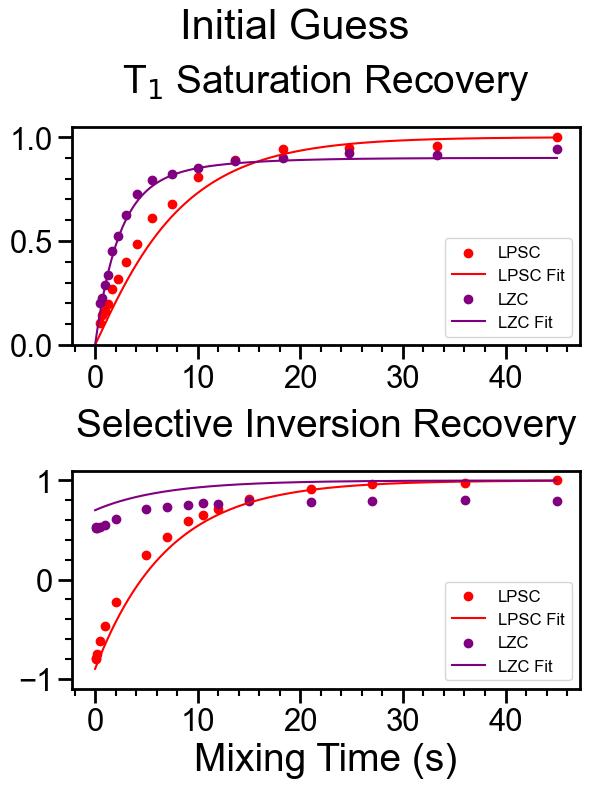

In [10]:
# INITIAL GUESS
smooth_data = calc_mags(params, const_dict, data_dict)

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                   data_dict[dataset_types[plotnum]]['intensities'].T[site],
                   c=['red','purple'][site], label=site_labels[site])
        ax.plot(smooth_data[dataset_types[plotnum]].T[0],
                smooth_data[dataset_types[plotnum]].T[site+1],
                   c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.1, 1.1])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.suptitle('Initial Guess')

fig.tight_layout()

In [11]:
result = minimize(calc_residuals, params, args=(const_dict, data_dict), method='leastsq')  # Use Levenberg-Marquardt minimization
report_fit(result)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 104
    # data points      = 64
    # variables        = 11
    chi-square         = 0.01890359
    reduced chi-square = 3.5667e-04
    Akaike info crit   = -498.146350
    Bayesian info crit = -474.398636
[[Variables]]
    rate:              0.03254069 +/- 0.00909632 (27.95%) (init = 0.05)
    lpsc_t1:           6.90374200 +/- 0.35364058 (5.12%) (init = 10)
    lzc_t1:            2.64443679 +/- 0.14729264 (5.57%) (init = 2.5)
    lpsc_satrec_minf:  0.97956192 +/- 0.00839304 (0.86%) (init = 1)
    lzc_satrec_minf:   0.91263909 +/- 0.00776910 (0.85%) (init = 0.9)
    lpsc_satrec_m0:    0.04692257 +/- 0.01158392 (24.69%) (init = 0)
    lzc_satrec_m0:     0.03580982 +/- 0.02100180 (58.65%) (init = 0)
    lpsc_sir_minf:     0.96620664 +/- 0.00937332 (0.97%) (init = 1)
    lzc_sir_minf:      0.80000000 +/- 0.00747990 (0.93%) (init = 1)
    lpsc_sir_m0:      -0.78988414 +/- 0.00924277 (1.17%) (init = -0.9)
    lzc_s

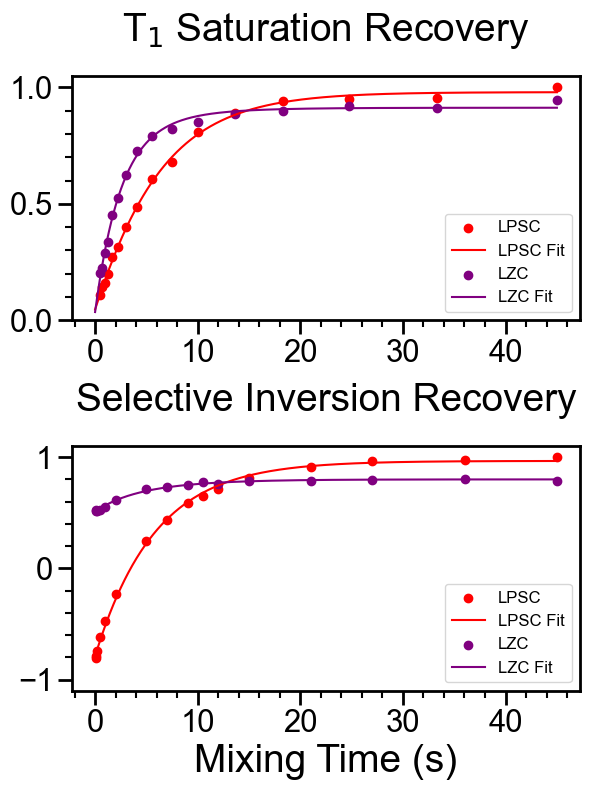

In [12]:
smooth_data = calc_mags(result.params, const_dict, data_dict)

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                   data_dict[dataset_types[plotnum]]['intensities'].T[site],
                   c=['red','purple'][site], label=site_labels[site])
        ax.plot(smooth_data[dataset_types[plotnum]].T[0],
                smooth_data[dataset_types[plotnum]].T[site+1],
                   c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.1, 1.1])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

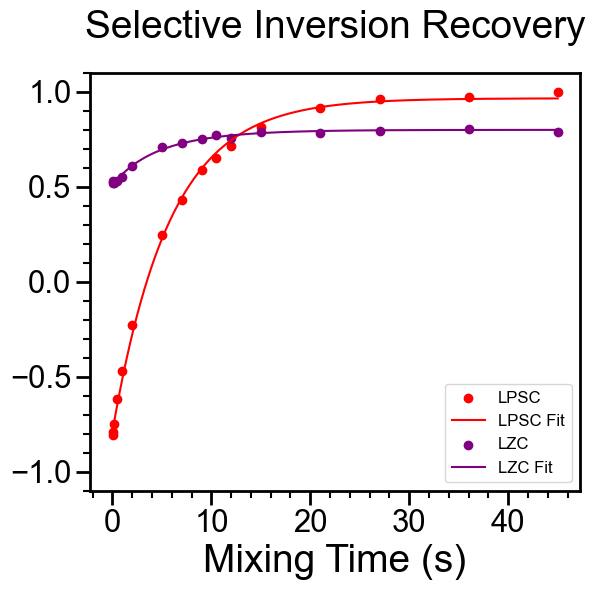

In [19]:
smooth_data = calc_mags(result.params, const_dict, data_dict)

fig, ax = plt.subplots(figsize=(6,6))
plotnum=1
for site in range(2):
    ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['red','purple'][site], label=site_labels[site])
    ax.plot(smooth_data[dataset_types[plotnum]].T[0],
            smooth_data[dataset_types[plotnum]].T[site+1],
                c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
ax.set_ylim([-1.1, 1.1])
ax.set_title('Selective Inversion Recovery')
ax.set_xlabel('Mixing Time (s)')

fig.tight_layout()

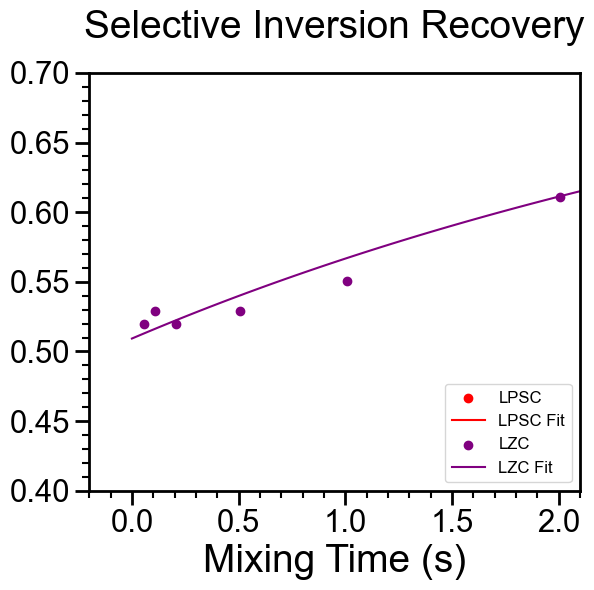

In [20]:
smooth_data = calc_mags(result.params, const_dict, data_dict)

fig, ax = plt.subplots(figsize=(6,6))
plotnum=1
for site in range(2):
    ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['red','purple'][site], label=site_labels[site])
    ax.plot(smooth_data[dataset_types[plotnum]].T[0],
            smooth_data[dataset_types[plotnum]].T[site+1],
                c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
ax.set_ylim([0.4, .7])
ax.set_xlim([-.2,2.1])
ax.set_title('Selective Inversion Recovery')
ax.set_xlabel('Mixing Time (s)')

fig.tight_layout()

# other temps

In [56]:
rates = [result.uvars['rate']]
set_temps = [10]

## 0C

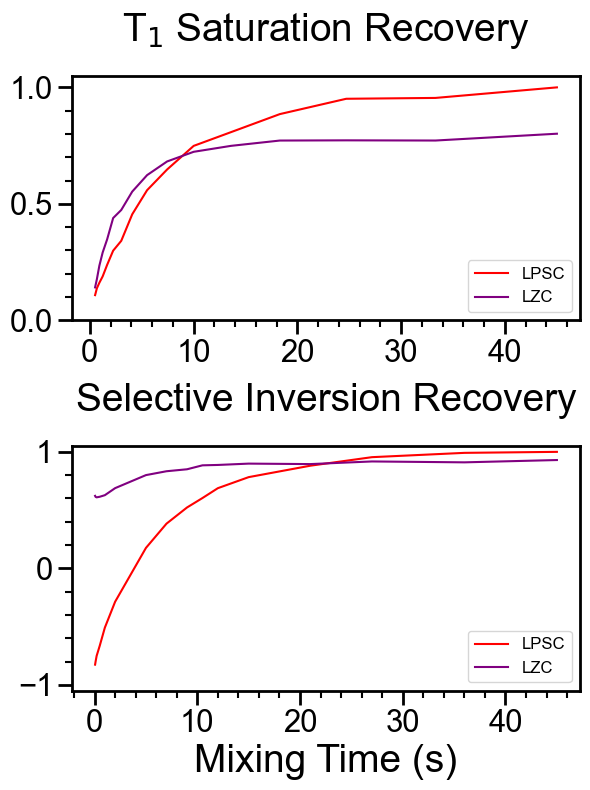

In [57]:
sirdata = read_t1ints(datadir+'/42/pdata/1/t1ints.txt')
satrecdata = read_t1ints(datadir+'/43/pdata/1/t1ints.txt')
data_dict = {'satrec':satrecdata, 'sir':sirdata}

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.plot(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['red','purple'][site], label=site_labels[site])
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.05, 1.05])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

In [58]:
satrecdata

{'time_points': array([ 0.5075,  0.6825,  0.9185,  1.2375,  1.6675,  2.2475,  3.0275,
         4.0875,  5.5175,  7.4475, 10.0075, 13.6075, 18.3075, 24.7075,
        33.3075, 45.0075]),
 'intensities': array([[0.10835287, 0.1415948 ],
        [0.13813276, 0.17757993],
        [0.16140084, 0.23471787],
        [0.18880751, 0.29141393],
        [0.2382761 , 0.34763112],
        [0.29917524, 0.43925309],
        [0.34133285, 0.47375509],
        [0.45542161, 0.55275726],
        [0.55873629, 0.62336491],
        [0.64757277, 0.68209591],
        [0.74891065, 0.72349029],
        [0.80793341, 0.74903961],
        [0.88525477, 0.7717876 ],
        [0.95107265, 0.77268508],
        [0.95470277, 0.77187957],
        [1.        , 0.80113935]])}

In [59]:
const_dict, _ = read_mch_file(f'{datadir}/{sir_exp}.mch')
const_dict['matrix']=const_dict.pop('matrices')[0]
const_dict

Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 22


{'title': 'Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 22',
 'n_sites': 2,
 'n_procs': 1,
 'matrix': array([[ 0.    , -1.    ],
        [-0.9366,  0.    ]])}

In [60]:
params_dict = {
    'rate': {
        'value': 0.05,  # in Hz
        'min': 1e-6,
        'max': 100,
        'vary': True},
    'lpsc_t1': {
        'value': 10,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lzc_t1': {
        'value': 2.5,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lpsc_satrec_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_satrec_minf': {
        'value': 0.9,
        'min': 0.75,
        'max': 1.1,
        'vary': True},
    'lpsc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lzc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lpsc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lpsc_sir_m0': {
        'value': -0.9,
        'min': -1,
        # 'max': sirdata['intensities'][0][0],
        'max': -0.5,
        'vary': True},
    'lzc_sir_m0': {
        'value': 0.7,
        # 'min': sirdata['intensities'][0][1],
        'min': 0.5,
        'max': 1,
        'vary': True},
}
params = create_params(**params_dict)
params.pretty_print()

result = minimize(calc_residuals, params, args=(const_dict, data_dict), method='leastsq')  # Use Levenberg-Marquardt minimization
report_fit(result)

Name                 Value      Min      Max   Stderr     Vary     Expr Brute_Step
lpsc_satrec_m0           0     -0.2      0.2     None     True     None     None
lpsc_satrec_minf         1      0.8      1.2     None     True     None     None
lpsc_sir_m0           -0.9       -1     -0.5     None     True     None     None
lpsc_sir_minf            1      0.8      1.2     None     True     None     None
lpsc_t1                 10    0.001    1e+05     None     True     None     None
lzc_satrec_m0            0     -0.2      0.2     None     True     None     None
lzc_satrec_minf        0.9     0.75      1.1     None     True     None     None
lzc_sir_m0             0.7      0.5        1     None     True     None     None
lzc_sir_minf             1      0.8      1.2     None     True     None     None
lzc_t1                 2.5    0.001    1e+05     None     True     None     None
rate                  0.05    1e-06      100     None     True     None     None
[[Fit Statistics]]
    # f

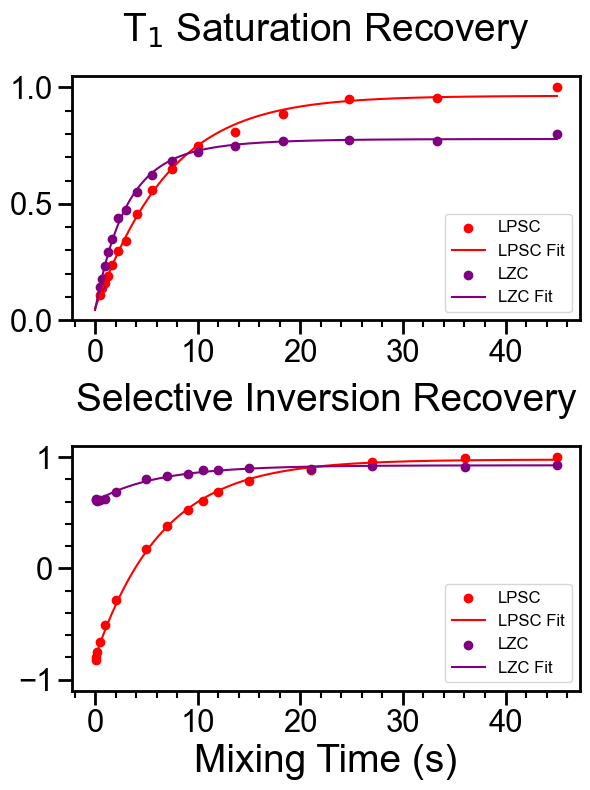

In [61]:
smooth_data = calc_mags(result.params, const_dict, data_dict)

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                   data_dict[dataset_types[plotnum]]['intensities'].T[site],
                   c=['red','purple'][site], label=site_labels[site])
        ax.plot(smooth_data[dataset_types[plotnum]].T[0],
                smooth_data[dataset_types[plotnum]].T[site+1],
                   c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.1, 1.1])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

In [62]:
rates.append(result.uvars['rate'])
set_temps.append(0)

## -10C

Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 62
Name                 Value      Min      Max   Stderr     Vary     Expr Brute_Step
lpsc_satrec_m0           0     -0.2      0.2     None     True     None     None
lpsc_satrec_minf         1      0.8      1.2     None     True     None     None
lpsc_sir_m0           -0.9       -1     -0.5     None     True     None     None
lpsc_sir_minf            1      0.8      1.2     None     True     None     None
lpsc_t1                 10    0.001    1e+05     None     True     None     None
lzc_satrec_m0            0     -0.2      0.2     None     True     None     None
lzc_satrec_minf        0.9     0.75      1.1     None     True     None     None
lzc_sir_m0             0.7      0.5        1     None     True     None     None
lzc_sir_minf             1      0.8      1.2     None     True     None     None
lzc_t1                 2.5    0.001    1e+05     None     True     None     None
rate        

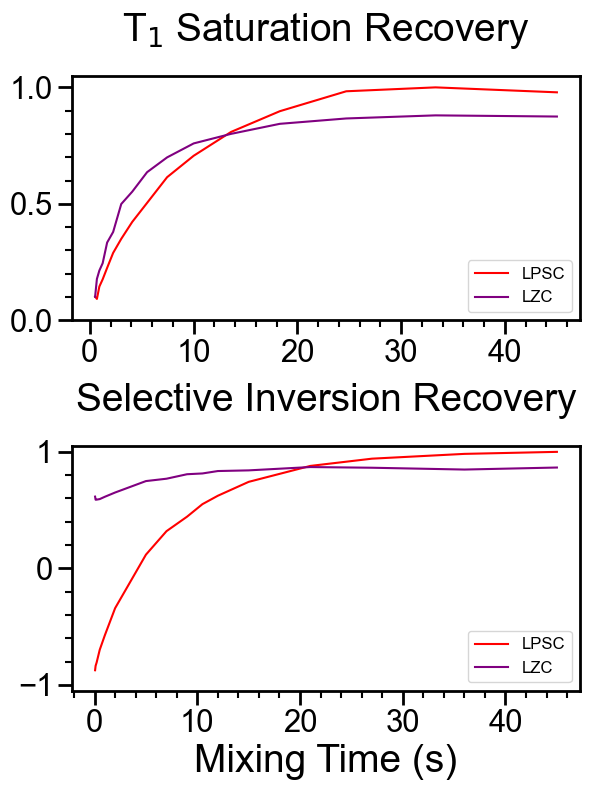

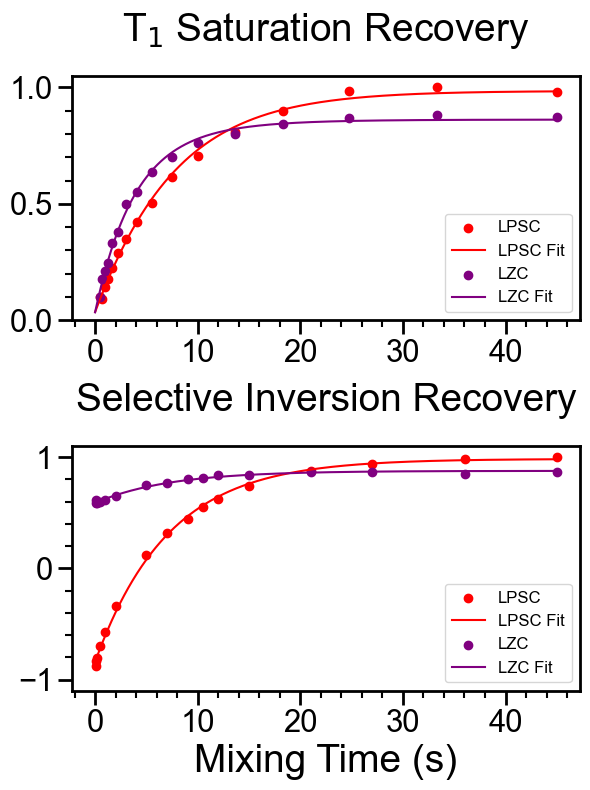

In [63]:
sirdata = read_t1ints(datadir+'/62/pdata/1/t1ints.txt')
satrecdata = read_t1ints(datadir+'/63/pdata/1/t1ints.txt')
const_dict, _ = read_mch_file(f'{datadir}/62.mch')
set_temps.append(-10)

const_dict['matrix']=const_dict.pop('matrices')[0]
data_dict = {'satrec':satrecdata, 'sir':sirdata}

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.plot(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['red','purple'][site], label=site_labels[site])
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.05, 1.05])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

params_dict = {
    'rate': {
        'value': 0.05,  # in Hz
        'min': 1e-6,
        'max': 100,
        'vary': True},
    'lpsc_t1': {
        'value': 10,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lzc_t1': {
        'value': 2.5,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lpsc_satrec_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_satrec_minf': {
        'value': 0.9,
        'min': 0.75,
        'max': 1.1,
        'vary': True},
    'lpsc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lzc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lpsc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lpsc_sir_m0': {
        'value': -0.9,
        'min': -1,
        # 'max': sirdata['intensities'][0][0],
        'max': -0.5,
        'vary': True},
    'lzc_sir_m0': {
        'value': 0.7,
        # 'min': sirdata['intensities'][0][1],
        'min': 0.5,
        'max': 1,
        'vary': True},
}
params = create_params(**params_dict)
params.pretty_print()

result = minimize(calc_residuals, params, args=(const_dict, data_dict), method='leastsq')  # Use Levenberg-Marquardt minimization
report_fit(result)

smooth_data = calc_mags(result.params, const_dict, data_dict)
fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                   data_dict[dataset_types[plotnum]]['intensities'].T[site],
                   c=['red','purple'][site], label=site_labels[site])
        ax.plot(smooth_data[dataset_types[plotnum]].T[0],
                smooth_data[dataset_types[plotnum]].T[site+1],
                   c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.1, 1.1])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')
fig.tight_layout()

rates.append(result.uvars['rate'])

## -20C

Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 82
Name                 Value      Min      Max   Stderr     Vary     Expr Brute_Step
lpsc_satrec_m0           0     -0.2      0.2     None     True     None     None
lpsc_satrec_minf         1      0.8      1.2     None     True     None     None
lpsc_sir_m0           -0.9       -1     -0.5     None     True     None     None
lpsc_sir_minf            1      0.8      1.2     None     True     None     None
lpsc_t1                 10    0.001    1e+05     None     True     None     None
lzc_satrec_m0            0     -0.2      0.2     None     True     None     None
lzc_satrec_minf        0.9     0.75      1.1     None     True     None     None
lzc_sir_m0             0.7      0.5        1     None     True     None     None
lzc_sir_minf             1      0.8      1.2     None     True     None     None
lzc_t1                 2.5    0.001    1e+05     None     True     None     None
rate        

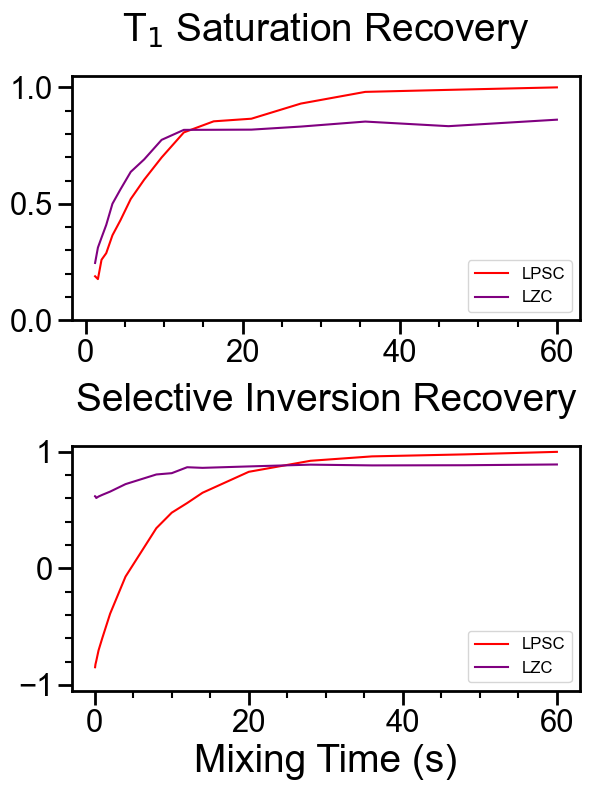

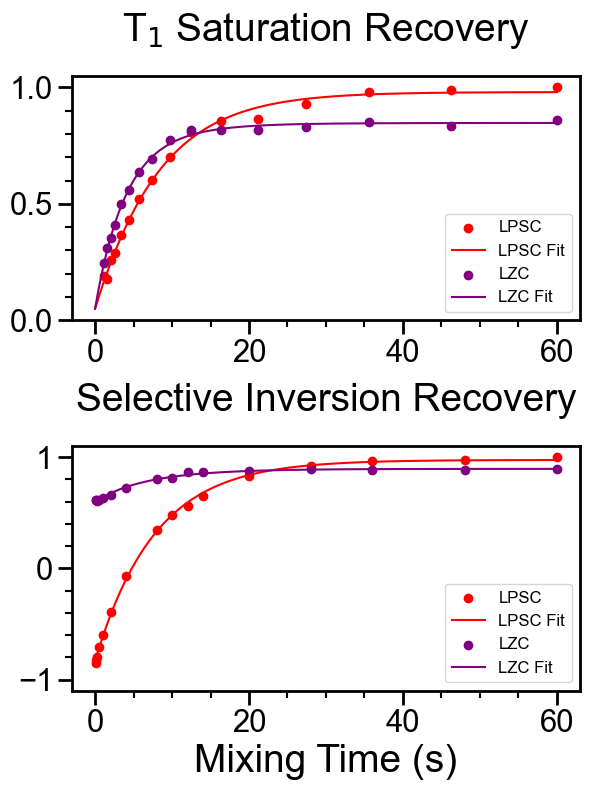

In [64]:
sirdata = read_t1ints(datadir+'/82/pdata/1/t1ints.txt')
satrecdata = read_t1ints(datadir+'/83/pdata/1/t1ints.txt')
const_dict, _ = read_mch_file(f'{datadir}/82.mch')
set_temps.append(-20)

const_dict['matrix']=const_dict.pop('matrices')[0]
data_dict = {'satrec':satrecdata, 'sir':sirdata}

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.plot(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['red','purple'][site], label=site_labels[site])
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.05, 1.05])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

params_dict = {
    'rate': {
        'value': 0.05,  # in Hz
        'min': 1e-6,
        'max': 100,
        'vary': True},
    'lpsc_t1': {
        'value': 10,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lzc_t1': {
        'value': 2.5,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lpsc_satrec_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_satrec_minf': {
        'value': 0.9,
        'min': 0.75,
        'max': 1.1,
        'vary': True},
    'lpsc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lzc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lpsc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lpsc_sir_m0': {
        'value': -0.9,
        'min': -1,
        # 'max': sirdata['intensities'][0][0],
        'max': -0.5,
        'vary': True},
    'lzc_sir_m0': {
        'value': 0.7,
        # 'min': sirdata['intensities'][0][1],
        'min': 0.5,
        'max': 1,
        'vary': True},
}
params = create_params(**params_dict)
params.pretty_print()

result = minimize(calc_residuals, params, args=(const_dict, data_dict), method='leastsq')  # Use Levenberg-Marquardt minimization
report_fit(result)

smooth_data = calc_mags(result.params, const_dict, data_dict)
fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                   data_dict[dataset_types[plotnum]]['intensities'].T[site],
                   c=['red','purple'][site], label=site_labels[site])
        ax.plot(smooth_data[dataset_types[plotnum]].T[0],
                smooth_data[dataset_types[plotnum]].T[site+1],
                   c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.1, 1.1])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')
fig.tight_layout()

rates.append(result.uvars['rate'])

## -30C

Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 105
Name                 Value      Min      Max   Stderr     Vary     Expr Brute_Step
lpsc_satrec_m0           0     -0.2      0.2     None     True     None     None
lpsc_satrec_minf       1.1      0.8      1.2     None     True     None     None
lpsc_sir_m0           -0.9       -1     -0.5     None     True     None     None
lpsc_sir_minf            1      0.8      1.2     None     True     None     None
lpsc_t1                 12    0.001    1e+05     None     True     None     None
lzc_satrec_m0            0     -0.2      0.2     None     True     None     None
lzc_satrec_minf        0.9     0.75      1.1     None     True     None     None
lzc_sir_m0             0.7      0.5        1     None     True     None     None
lzc_sir_minf             1      0.8      1.2     None     True     None     None
lzc_t1                 2.5    0.001    1e+05     None     True     None     None
rate       

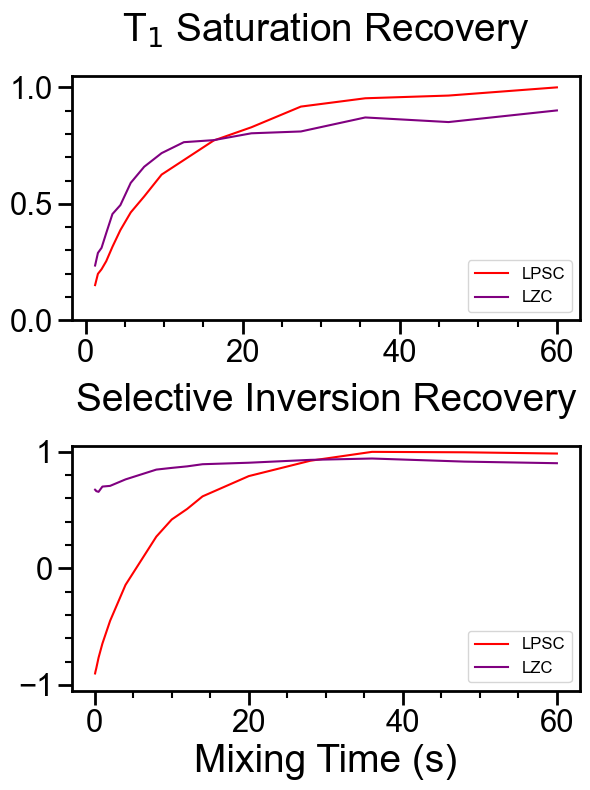

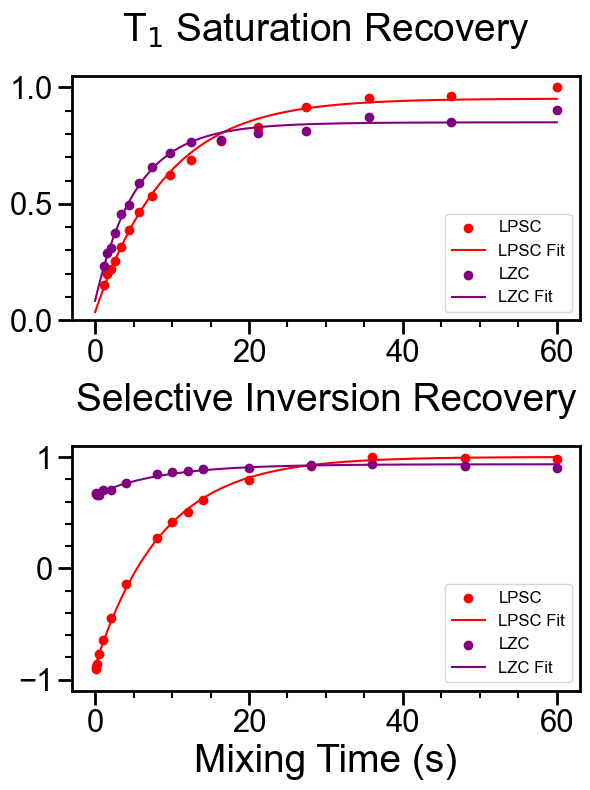

In [65]:
sirdata = read_t1ints(datadir+'/105/pdata/1/t1ints.txt')
satrecdata = read_t1ints(datadir+'/106/pdata/1/t1ints.txt')
const_dict, _ = read_mch_file(f'{datadir}/105.mch')
set_temps.append(-30)

const_dict['matrix']=const_dict.pop('matrices')[0]
data_dict = {'satrec':satrecdata, 'sir':sirdata}

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.plot(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['red','purple'][site], label=site_labels[site])
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.05, 1.05])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

params_dict = {
    'rate': {
        'value': 0.05,  # in Hz
        'min': 1e-6,
        'max': 100,
        'vary': True},
    'lpsc_t1': {
        'value': 12,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lzc_t1': {
        'value': 2.5,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lpsc_satrec_minf': {
        'value': 1.1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_satrec_minf': {
        'value': 0.9,
        'min': 0.75,
        'max': 1.1,
        'vary': True},
    'lpsc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lzc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lpsc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lpsc_sir_m0': {
        'value': -0.9,
        'min': -1,
        # 'max': sirdata['intensities'][0][0],
        'max': -0.5,
        'vary': True},
    'lzc_sir_m0': {
        'value': 0.7,
        # 'min': sirdata['intensities'][0][1],
        'min': 0.5,
        'max': 1,
        'vary': True},
}
params = create_params(**params_dict)
params.pretty_print()

result = minimize(calc_residuals, params, args=(const_dict, data_dict), method='leastsq')  # Use Levenberg-Marquardt minimization
report_fit(result)

smooth_data = calc_mags(result.params, const_dict, data_dict)
fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                   data_dict[dataset_types[plotnum]]['intensities'].T[site],
                   c=['red','purple'][site], label=site_labels[site])
        ax.plot(smooth_data[dataset_types[plotnum]].T[0],
                smooth_data[dataset_types[plotnum]].T[site+1],
                   c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.1, 1.1])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')
fig.tight_layout()

rates.append(result.uvars['rate'])

# Arrhenius

In [66]:
set_temps

[10, 0, -10, -20, -30]

In [67]:
rates = np.array(rates)
rates

array([0.03254069351051211+/-0.009096324479869812,
       0.037356700740243366+/-0.009091956591258934,
       0.021852551778855027+/-0.00644805858417131,
       0.018675779613800417+/-0.005680125465476746,
       0.013242185868710924+/-0.005451542126360112], dtype=object)

In [68]:
temps_c = np.array([32.51, 27.83, 18.61, 8.92, 4.08])

In [69]:
temps_k = 273.15+temps_c
inv_t = 1000/temps_k

In [70]:
from uncertainties.umath import log

log_k = []
log_k_err = []
log_k_t = []
log_k_t_err = []
for rate, temp_k in zip(rates,temps_k):
    uvar = log(rate)
    log_k.append(uvar.n)
    log_k_err.append(uvar.s)

    uvar = log(rate/temp_k)
    log_k_t.append(uvar.n)
    log_k_t_err.append(uvar.s)
log_k

[-3.4252638648642026,
 -3.2872429794717077,
 -3.823437578041896,
 -3.9805278024463706,
 -4.324347646276003]

In [71]:
log_k_t_err

[0.27953689668387954,
 0.2433822155355496,
 0.2950711957772631,
 0.3041439545195443,
 0.41167992810319903]

In [72]:
log_k_err

[0.2795368966838795,
 0.24338221553554953,
 0.2950711957772631,
 0.3041439545195443,
 0.41167992810319903]

Text(0.45, 0.85, 'E$_a$ = 23.44 kJ/mol')

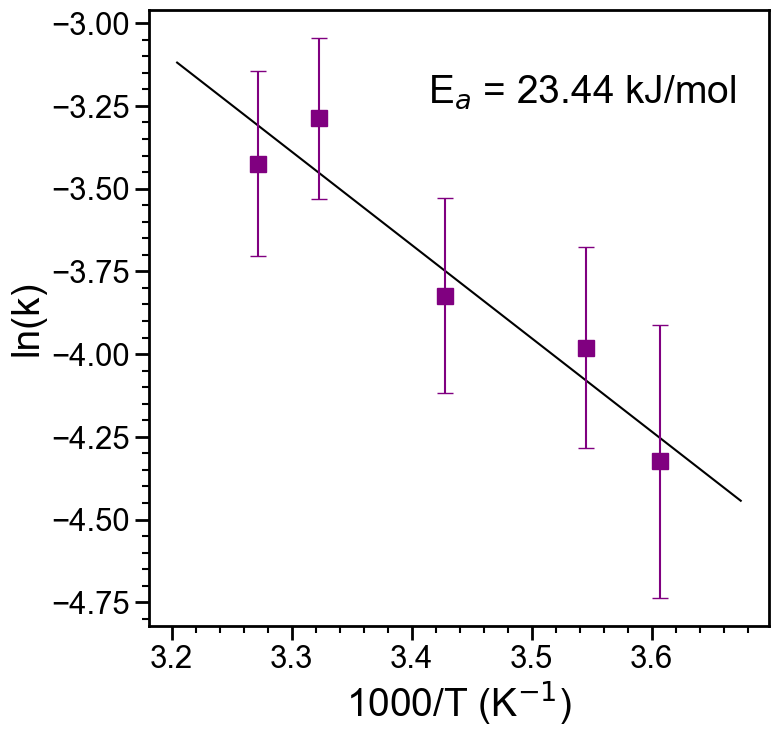

In [73]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8,8))

ax.set_xlabel('1000/T (K$^{-1}$)')
ax.set_ylabel('ln(k)')

fit = linregress(inv_t, log_k)
x_span = max(inv_t) - min(inv_t)
x_min = min(inv_t) - 0.2 * x_span
x_max = max(inv_t) + 0.2 * x_span
x_fit = np.linspace(x_min, x_max, 100)
y_fit = x_fit*fit[0] + fit[1]

ax.plot(x_fit, y_fit, c='k')
ax.errorbar(inv_t, log_k, yerr=log_k_err, marker='s', markersize=12, c='purple', linestyle='', capsize=6)

E_a = -8.3145*fit[0]
ax.text(0.45, 0.85, f"E$_a$ = {E_a:.2f} kJ/mol", transform=ax.transAxes, fontsize=28)

Text(0.45, 0.85, 'E$_a$ = 217.8 meV')

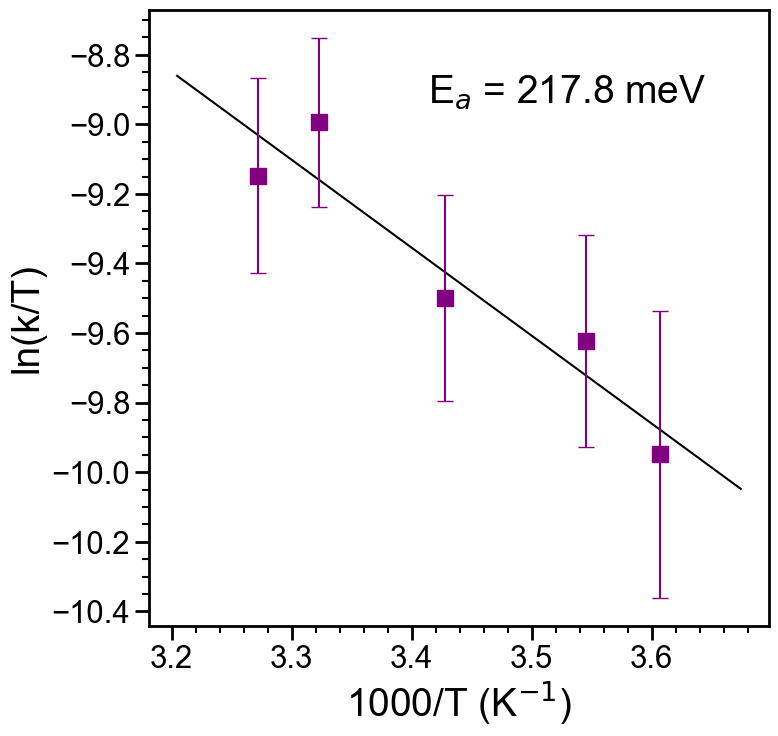

In [74]:
fit = linregress(inv_t, log_k_t)
x_span = max(inv_t) - min(inv_t)
x_min = min(inv_t) - 0.2 * x_span
x_max = max(inv_t) + 0.2 * x_span
x_fit = np.linspace(x_min, x_max, 100)
y_fit = x_fit*fit[0] + fit[1]

fig, ax = plt.subplots(figsize=(8,8))
ax.set_xlabel('1000/T (K$^{-1}$)')
ax.set_ylabel('ln(k/T)')
ax.plot(x_fit, y_fit, c='k')
ax.errorbar(inv_t, log_k_t, yerr=log_k_t_err, marker='s', markersize=12, c='purple', linestyle='', capsize=6)

E_a = -8.617e1*fit[0]
ax.text(0.45, 0.85, f"E$_a$ = {E_a:.1f} meV", transform=ax.transAxes, fontsize=28)

# Trying to replicate with new rotor and pellet

Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.09.10_6Li_LZC+LPSC exp no 102
Name                 Value      Min      Max   Stderr     Vary     Expr Brute_Step
lpsc_satrec_m0           0     -0.2      0.2     None     True     None     None
lpsc_satrec_minf       1.1      0.8      1.2     None     True     None     None
lpsc_sir_m0           -0.9       -1     -0.5     None     True     None     None
lpsc_sir_minf            1      0.8      1.2     None     True     None     None
lpsc_t1                 12    0.001    1e+05     None     True     None     None
lzc_satrec_m0            0     -0.2      0.2     None     True     None     None
lzc_satrec_minf        0.9     0.75      1.1     None     True     None     None
lzc_sir_m0             0.7      0.5        1     None     True     None     None
lzc_sir_minf             1      0.8      1.2     None     True     None     None
lzc_t1                 2.5    0.001    1e+05     None     True     None     None
rate       

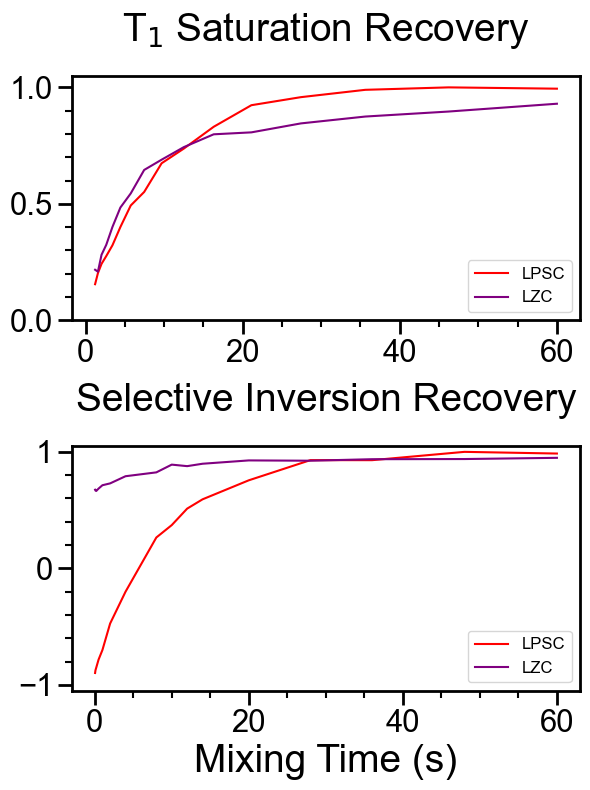

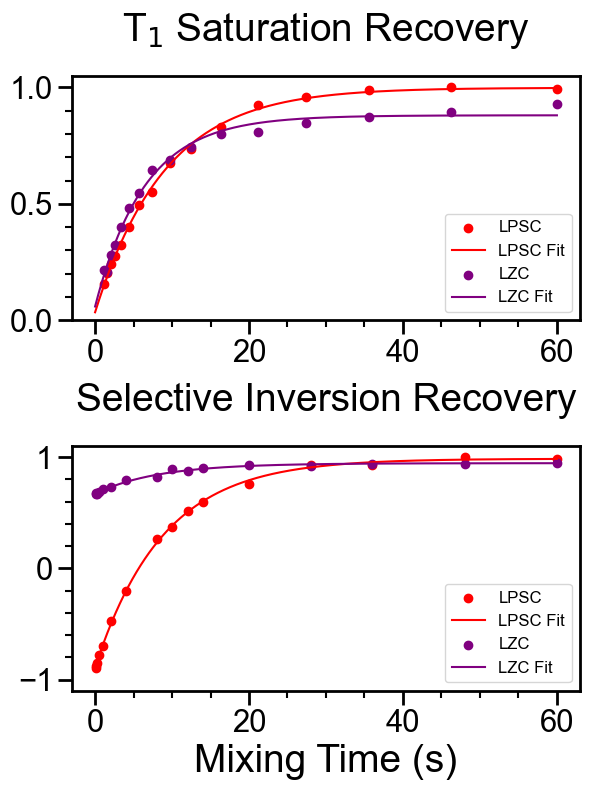

In [22]:
try2dir = '/Users/tylerpennebaker/Library/CloudStorage/Box-Box/LGES subgroup/FRL II/Raw data/Selective Inversion/NMR Data/data/500.TP-2025.09.10_6Li_LZC+LPSC'
sirdata = read_t1ints(try2dir+'/102/pdata/1/t1ints.txt')
satrecdata = read_t1ints(try2dir+'/103/pdata/1/t1ints.txt')
const_dict, _ = read_mch_file(f'{try2dir}/102.mch')

const_dict['matrix']=const_dict.pop('matrices')[0]
data_dict = {'satrec':satrecdata, 'sir':sirdata}

fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.plot(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['red','purple'][site], label=site_labels[site])
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.05, 1.05])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

params_dict = {
    'rate': {
        'value': 0.05,  # in Hz
        'min': 1e-6,
        'max': 100,
        'vary': True},
    'lpsc_t1': {
        'value': 12,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lzc_t1': {
        'value': 2.5,  # in s
        'min': 0.001,
        'max': 1e5,
        'vary': True},
    'lpsc_satrec_minf': {
        'value': 1.1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_satrec_minf': {
        'value': 0.9,
        'min': 0.75,
        'max': 1.1,
        'vary': True},
    'lpsc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lzc_satrec_m0': {
        'value': 0,
        'min': -0.2,
        'max': 0.2,
        'vary': True},
    'lpsc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lzc_sir_minf': {
        'value': 1,
        'min': 0.8,
        'max': 1.2,
        'vary': True},
    'lpsc_sir_m0': {
        'value': -0.9,
        'min': -1,
        # 'max': sirdata['intensities'][0][0],
        'max': -0.5,
        'vary': True},
    'lzc_sir_m0': {
        'value': 0.7,
        # 'min': sirdata['intensities'][0][1],
        'min': 0.5,
        'max': 1,
        'vary': True},
}
params = create_params(**params_dict)
params.pretty_print()

result = minimize(calc_residuals, params, args=(const_dict, data_dict), method='leastsq')  # Use Levenberg-Marquardt minimization
report_fit(result)

smooth_data = calc_mags(result.params, const_dict, data_dict)
fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                   data_dict[dataset_types[plotnum]]['intensities'].T[site],
                   c=['red','purple'][site], label=site_labels[site])
        ax.plot(smooth_data[dataset_types[plotnum]].T[0],
                smooth_data[dataset_types[plotnum]].T[site+1],
                   c=['red','purple'][site], label=site_labels[site]+' Fit')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.1, 1.1])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')
fig.tight_layout()

## Overlay old and new -30C data

Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 105
Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.09.10_6Li_LZC+LPSC exp no 102


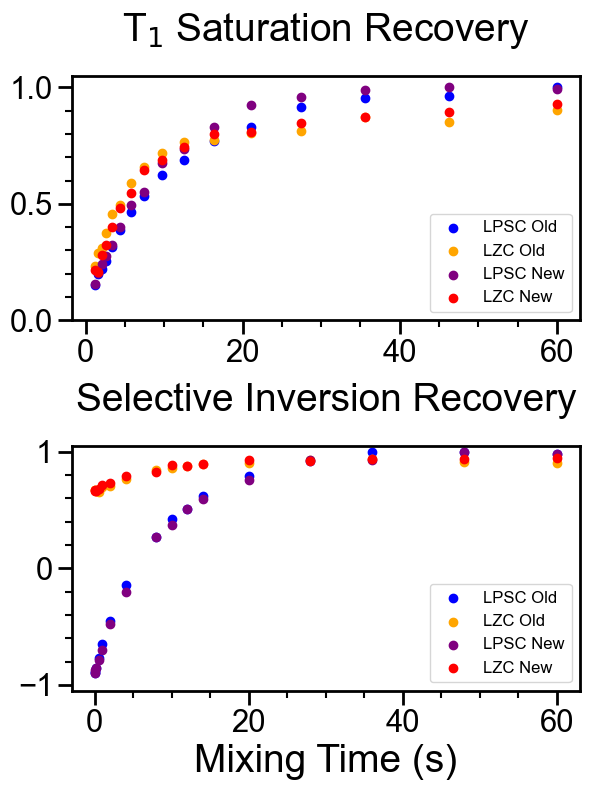

In [31]:
sirdata = read_t1ints(datadir+'/105/pdata/1/t1ints.txt')
satrecdata = read_t1ints(datadir+'/106/pdata/1/t1ints.txt')
const_dict, _ = read_mch_file(f'{datadir}/105.mch')

const_dict['matrix']=const_dict.pop('matrices')[0]
data_dict = {'satrec':satrecdata, 'sir':sirdata}


fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['blue','orange'][site], label=site_labels[site]+' Old')
    ax.legend(loc='lower right')

###

try2dir = '/Users/tylerpennebaker/Library/CloudStorage/Box-Box/LGES subgroup/FRL II/Raw data/Selective Inversion/NMR Data/data/500.TP-2025.09.10_6Li_LZC+LPSC'
sirdata = read_t1ints(try2dir+'/102/pdata/1/t1ints.txt')
satrecdata = read_t1ints(try2dir+'/103/pdata/1/t1ints.txt')
const_dict, _ = read_mch_file(f'{try2dir}/102.mch')

const_dict['matrix']=const_dict.pop('matrices')[0]
data_dict = {'satrec':satrecdata, 'sir':sirdata}

for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['purple','red'][site], label=site_labels[site]+' New')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.05, 1.05])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()

Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 105
Specifying vary: True
Mechanism title: Extracted from 500.TP-2025.06.18_6Li_LZC+LPSC exp no 22


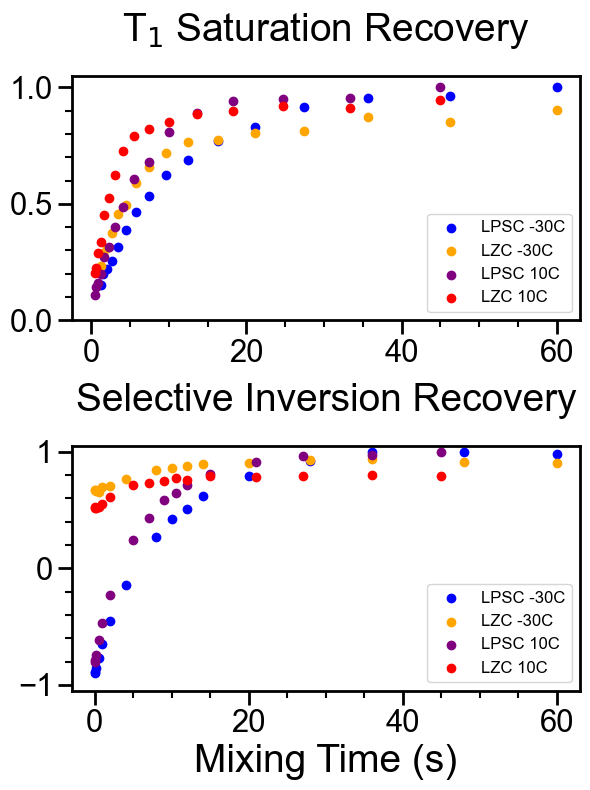

In [32]:
sirdata = read_t1ints(datadir+'/105/pdata/1/t1ints.txt')
satrecdata = read_t1ints(datadir+'/106/pdata/1/t1ints.txt')
const_dict, _ = read_mch_file(f'{datadir}/105.mch')

const_dict['matrix']=const_dict.pop('matrices')[0]
data_dict = {'satrec':satrecdata, 'sir':sirdata}


fig, axs = plt.subplots(2, figsize=(6,8))
for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['blue','orange'][site], label=site_labels[site]+' -30C')
    ax.legend(loc='lower right')

###

sirdata = read_t1ints(datadir+'/22/pdata/1/t1ints.txt')
satrecdata = read_t1ints(datadir+'/23/pdata/1/t1ints.txt')
const_dict, _ = read_mch_file(f'{datadir}/22.mch')

const_dict['matrix']=const_dict.pop('matrices')[0]
data_dict = {'satrec':satrecdata, 'sir':sirdata}

for plotnum in range(2):
    ax = axs[plotnum]
    for site in range(2):
        ax.scatter(data_dict[dataset_types[plotnum]]['time_points'],
                data_dict[dataset_types[plotnum]]['intensities'].T[site],
                c=['purple','red'][site], label=site_labels[site]+' 10C')
    ax.legend(loc='lower right')
axs[0].set_ylim([0, 1.05])
axs[0].set_title('T$_1$ Saturation Recovery')
axs[1].set_ylim([-1.05, 1.05])
axs[1].set_title('Selective Inversion Recovery')
axs[1].set_xlabel('Mixing Time (s)')

fig.tight_layout()